<a href="https://colab.research.google.com/github/anis2507/Amali_DKB3263/blob/main/Amali1_DKB3263_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# 7.2.1 Import & Setup Library
# ==========================================
import matplotlib.pyplot as plt  # Digunakan untuk memplot graf loss dan ketepatan (accuracy)
import torch  # Library utama PyTorch untuk operasi tensor dan pemodelan
import torch.nn as nn  # Modul neural network (mengandungi layer seperti Linear, ReLU)
import torch.optim as optim  # Modul optimizer (contoh: Adam, SGD)
from torch.utils.data import DataLoader  # Digunakan untuk memuatkan data dalam bentuk batch
from torchvision import datasets, transforms  # Menyediakan dataset MNIST dan transformasi imej

# Menetapkannya supaya latihan berjalan pada GPU jika ada, jika tiada ia akan guna CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

100%|██████████| 9.91M/9.91M [00:00<00:00, 109MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 39.8MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 82.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.26MB/s]


--- Melatih Model 1 (Learning Rate = 0.001) ---
Epoch [1/5] | Loss: 0.3391 | Accuracy: 94.65%
Epoch [2/5] | Loss: 0.1505 | Accuracy: 96.36%
Epoch [3/5] | Loss: 0.1039 | Accuracy: 97.17%
Epoch [4/5] | Loss: 0.0792 | Accuracy: 97.62%
Epoch [5/5] | Loss: 0.0618 | Accuracy: 97.59%

--- Melatih Model 2 (Learning Rate = 0.01) ---
Epoch [1/5] | Loss: 0.2245 | Accuracy: 95.52%
Epoch [2/5] | Loss: 0.1331 | Accuracy: 96.26%
Epoch [3/5] | Loss: 0.1074 | Accuracy: 96.36%
Epoch [4/5] | Loss: 0.1010 | Accuracy: 96.25%
Epoch [5/5] | Loss: 0.0893 | Accuracy: 96.19%


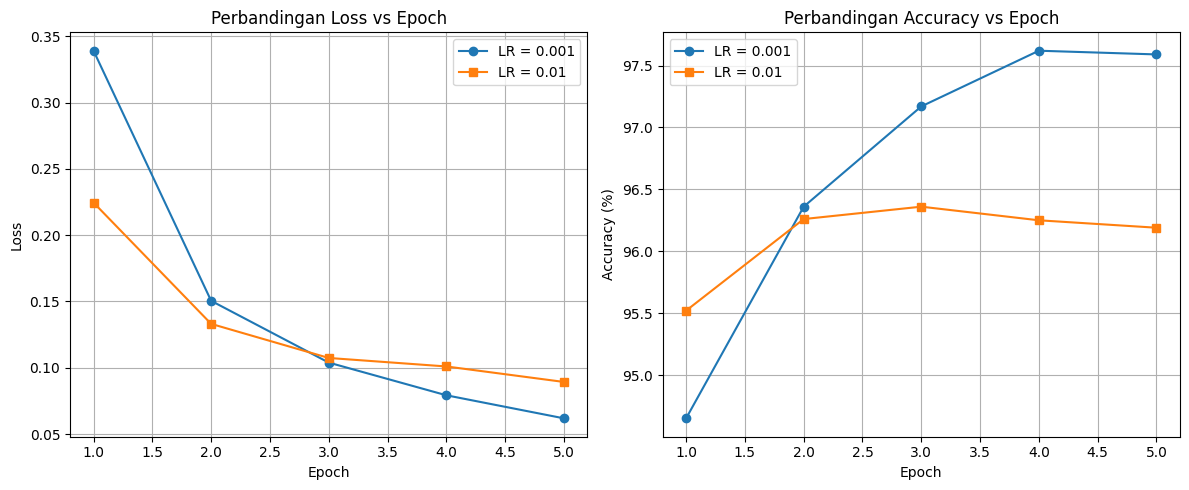

In [1]:
# ==========================================
# 7.2.1 Import & Setup Library
# ==========================================
import matplotlib.pyplot as plt  # Digunakan untuk memplot graf loss dan ketepatan (accuracy)
import torch  # Library utama PyTorch untuk operasi tensor dan pemodelan
import torch.nn as nn  # Modul neural network (mengandungi layer seperti Linear, ReLU)
import torch.optim as optim  # Modul optimizer (contoh: Adam, SGD)
from torch.utils.data import DataLoader  # Digunakan untuk memuatkan data dalam bentuk batch
from torchvision import datasets, transforms  # Menyediakan dataset MNIST dan transformasi imej

# Menetapkannya supaya latihan berjalan pada GPU jika ada, jika tiada ia akan guna CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 7.2.2 Load & Preprocess Dataset MNIST
# ==========================================
# Menentukan transformasi: Mengubah imej kepada Tensor dan meletakkan julat piksel dari [0, 255] ke [0, 1]
transform = transforms.Compose([transforms.ToTensor()])

# Muat turun dan sediakan dataset Latihan (Training Data)
train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)

# Muat turun dan sediakan dataset Ujian (Test Data)
test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)


# ==========================================
# 7.2.3 Bina Model ANN
# ==========================================
class SimpleANN(nn.Module):

    def __init__(self, input_size=28 * 28, hidden_size=128, num_classes=10):
        super(SimpleANN, self).__init__()
        # 1. Input Layer ke Hidden Layer (Imej MNIST bersaiz 28x28 = 784 piksel)
        self.fc1 = nn.Linear(input_size, hidden_size)

        # 2. Fungsi Aktivasi (ReLU)
        self.relu = nn.ReLU()

        # 3. Hidden Layer ke Output Layer (10 kelas untuk digit 0 hingga 9)
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # Meratakan imej 2D (28x28) menjadi vektor 1D bersaiz 784
        x = x.view(x.size(0), -1)

        # Melalui hidden layer dan fungsi aktivasi
        out = self.fc1(x)
        out = self.relu(out)

        # Melalui output layer
        out = self.fc2(out)
        return out


# ==========================================
# Fungsi untuk Latihan dan Penilaian Model
# ==========================================
def train_and_evaluate(learning_rate, batch_size=64, epochs=5):
    # Sediakan DataLoader untuk membahagikan data kepada batch
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False
    )

    # Inisialisasi model dan hantar ke peranti (CPU/GPU)
    model = SimpleANN().to(device)

    # 7.2.4 Definisi Loss Function & Optimizer
    criterion = nn.CrossEntropyLoss()  # Loss function untuk klasifikasi pelbagai kelas
    optimizer = optim.Adam(
        model.parameters(), lr=learning_rate
    )  # Optimizer Adam

    history_loss = []  # Menyimpan nilai loss untuk setiap epoch
    history_acc = []  # Menyimpan nilai ketepatan untuk setiap epoch

    # Loop Latihan mengikut jumlah Epoch
    for epoch in range(epochs):
        model.train()  # Tetapkan model ke mod latihan
        running_loss = 0.0

        for images, labels in train_loader:
            # Hantar data imej dan label ke CPU/GPU
            images, labels = images.to(device), labels.to(device)

            # 7.2.5 Training Loop (Forward, Backward, Update)
            optimizer.zero_grad()  # Kosongkan kecerunan (gradient) terdahulu
            outputs = model(images)  # Forward pass: Kiralapan output
            loss = criterion(outputs, labels)  # Kirakan loss (kerugian)
            loss.backward()  # Backward pass: Kira kecerunan (gradient)
            optimizer.step()  # Kemaskini berat (weights) model

            running_loss += loss.item()

        # Kirakan purata loss bagi epoch ini
        epoch_loss = running_loss / len(train_loader)
        history_loss.append(epoch_loss)

        # 7.2.6 Validation/Testing Accuracy
        model.eval()  # Tetapkan model ke mod penilaian
        correct = 0
        total = 0

        with torch.no_grad():  # Matikan pengiraan gradient untuk tingkatkan kelajuan ujian
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(
                    outputs.data, 1
                )  # Ambil indeks kelas dengan kebarangkalian tertinggi
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_acc = 100 * correct / total
        history_acc.append(epoch_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%"
        )

    return history_loss, history_acc


# ==========================================
# 6.2 & 7.2.7 Hyperparameter Tuning (Perbandingan)
# ==========================================
epochs = 5
batch_size = 64

# Menguji Model 1: Learning Rate = 0.001 (Standard)
print("--- Melatih Model 1 (Learning Rate = 0.001) ---")
loss_lr1, acc_lr1 = train_and_evaluate(
    learning_rate=0.001, batch_size=batch_size, epochs=epochs
)

# Menguji Model 2: Learning Rate = 0.01 (Lebih Tinggi)
print("\n--- Melatih Model 2 (Learning Rate = 0.01) ---")
loss_lr2, acc_lr2 = train_and_evaluate(
    learning_rate=0.01, batch_size=batch_size, epochs=epochs
)


# ==========================================
# 6.3 & 7.3.4 Plot Graf Loss vs Epoch & Accuracy vs Epoch
# ==========================================
plt.figure(figsize=(12, 5))

# Graf 1: Loss vs Epoch
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), loss_lr1, label="LR = 0.001", marker="o")
plt.plot(range(1, epochs + 1), loss_lr2, label="LR = 0.01", marker="s")
plt.title("Perbandingan Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Graf 2: Accuracy vs Epoch
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), acc_lr1, label="LR = 0.001", marker="o")
plt.plot(range(1, epochs + 1), acc_lr2, label="LR = 0.01", marker="s")
plt.title("Perbandingan Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

# Paparkan Graf
plt.tight_layout()
plt.show()